# County-level model of frequent mental distress

Companion to `Health.ipynb`. The original model is fit on 52 state averages. This notebook fits the same two-predictor model on **U.S. counties**, using data pulled directly from the CDC PLACES API, so no local file or Google Drive is needed.

What changes compared with the state model:

- **Unit of analysis:** counties keyed by FIPS code (`LocationID`), not by county name. Names repeat across states, such as Baltimore city vs Baltimore County or ~30 "Washington" counties.
- **Missing data:** counties missing any of the six measures are dropped, not filled with the mean.
- **Validation:** cross-validation grouped by state, so the test states are never seen in training. Plus an out-of-time test: train on 2022 data, test on 2023 data.
- **Ablation:** depression only vs financial threat only vs both, compared against a predict-the-mean baseline and a random forest.
- **Crude vs age-adjusted prevalence.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from urllib.parse import urlencode
from sklearn.model_selection import KFold, GroupKFold, cross_validate, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_squared_error

## 1. Load CDC PLACES county data

Two releases. The 2025 release is the latest available (BRFSS 2023 data). The 2024 release (BRFSS 2022 data) is used as an independent earlier year.

In [2]:
MEASURES = {
    "Frequent mental distress among adults": "distress",
    "Depression among adults": "depression",
    "Housing insecurity in the past 12 months among adults": "housing",
    "Utility services shut-off threat in the past 12 months among adults": "utility",
    "Food insecurity in the past 12 months among adults": "food",
    "Received food stamps in the past 12 months among adults": "stamps",
}
FINANCIAL = ["housing", "utility", "food", "stamps"]
RELEASES = {
    "2023": "swc5-untb",  # PLACES 2025 release, BRFSS 2023 data
    "2022": "fu4u-a9bh",  # PLACES 2024 release, BRFSS 2022 data
}

def load_places(dataset_id):
    measure_list = ",".join(f"'{m}'" for m in MEASURES)
    query = urlencode({
        "$select": "year,stateabbr,locationname,locationid,measure,data_value_type,data_value",
        "$where": f"measure in({measure_list}) AND data_value_type in('Crude prevalence','Age-adjusted prevalence')",
        "$limit": 100000,
    })
    raw = pd.read_csv(f"https://chronicdata.cdc.gov/resource/{dataset_id}.csv?{query}", dtype={"locationid": str})
    raw = raw[raw["stateabbr"] != "US"]
    raw["measure"] = raw["measure"].map(MEASURES)
    return raw

raw = {year: load_places(ds) for year, ds in RELEASES.items()}
for year, df in raw.items():
    print(f"{year} data: {len(df):,} rows, {df['locationid'].nunique():,} counties, survey year(s) {sorted(df['year'].unique())}")

2023 data: 30,220 rows, 2,957 counties, survey year(s) [np.int64(2023)]
2022 data: 31,912 rows, 3,144 counties, survey year(s) [np.int64(2022)]


In [3]:
def county_table(df, value_type):
    wide = (df[df["data_value_type"] == value_type]
            .pivot_table(index=["locationid", "stateabbr", "locationname"], columns="measure", values="data_value")
            .reset_index())
    # skipna=False: a county needs all four components to get a financial-threat score
    wide["financial_threat"] = wide[FINANCIAL].mean(axis=1, skipna=False)
    return wide

crude = {year: county_table(df, "Crude prevalence") for year, df in raw.items()}
adjusted = {year: county_table(df, "Age-adjusted prevalence") for year, df in raw.items()}

## 2. Coverage and missing data

The four financial measures come from a BRFSS module that only some states field each year. Rather than filling those states with the national mean, which is what the state model does, we keep only counties with all six measures and say which states drop out.

In [4]:
coverage = []
for year, d in crude.items():
    has_fin = d[FINANCIAL].notna().all(axis=1)
    state_has_fin = has_fin.groupby(d["stateabbr"]).any()
    coverage.append({
        "data year": year,
        "counties": len(d),
        "with all 6 measures": int((has_fin & d["distress"].notna() & d["depression"].notna()).sum()),
        "states kept": int(state_has_fin.sum()),
        "states with no financial data": ", ".join(sorted(state_has_fin[~state_has_fin].index)),
    })
pd.DataFrame(coverage)

,data year,counties,with all 6 measures,states kept,states with no financial data
0,2023,2956,2299,40,"CO, FL, OR, SD, TN, TX, VT, WA, WY"
1,2022,3144,2417,40,"AR, CO, HI, IL, LA, ND, NY, OR, PA, SD, VA"


In [5]:
model_cols = ["distress", "depression", "financial_threat"]
d23 = crude["2023"].dropna(subset=model_cols)
d22 = crude["2022"].dropna(subset=model_cols)
a23 = adjusted["2023"].dropna(subset=model_cols)

print(f"2023 analysis sample: {len(d23):,} counties in {d23['stateabbr'].nunique()} states")
print(f"2022 analysis sample: {len(d22):,} counties in {d22['stateabbr'].nunique()} states")
print(f"Correlation between depression and financial threat (2023): {d23['depression'].corr(d23['financial_threat']):.3f}")

2023 analysis sample: 2,299 counties in 40 states
2022 analysis sample: 2,417 counties in 40 states
Correlation between depression and financial threat (2023): 0.075


## 3. Which predictors matter, and does the model generalize to new states?

Every model is scored two ways:

- **Random 5-fold:** counties shuffled at random. Neighbouring counties from the same state end up in both train and test, which flatters the score.
- **State-grouped 5-fold:** whole states are held out. This answers the harder question: does the model work in a state it has never seen?

In [6]:
CANDIDATES = {
    "Baseline (predict the mean)": (["depression"], DummyRegressor()),
    "Depression only": (["depression"], LinearRegression()),
    "Financial threat only": (["financial_threat"], LinearRegression()),
    "Depression + financial threat": (["depression", "financial_threat"], LinearRegression()),
    "Random forest (both predictors)": (["depression", "financial_threat"],
                                        RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)),
}

def compare_models(d):
    schemes = {
        "random": (KFold(n_splits=5, shuffle=True, random_state=42), None),
        "state-grouped": (GroupKFold(n_splits=5), d["stateabbr"]),
    }
    rows = []
    for name, (cols, est) in CANDIDATES.items():
        row = {"model": name}
        for scheme, (cv, groups) in schemes.items():
            s = cross_validate(est, d[cols], d["distress"], cv=cv, groups=groups,
                               scoring=("r2", "neg_root_mean_squared_error"))
            row[f"R2 {scheme}"] = s["test_r2"].mean()
            row[f"R2 {scheme} std"] = s["test_r2"].std()
            row[f"RMSE {scheme}"] = -s["test_neg_root_mean_squared_error"].mean()
        rows.append(row)
    return pd.DataFrame(rows).set_index("model")

results_23 = compare_models(d23)
results_23.round(3)

,R2 random,R2 random std,RMSE random,R2 state-grouped,R2 state-grouped std,RMSE state-grouped
model,,,,,,
Baseline (predict the mean),-0.004,0.002,1.981,-0.176,0.253,2.009
Depression only,0.398,0.035,1.533,0.245,0.279,1.579
Financial threat only,0.461,0.044,1.449,0.386,0.101,1.457
Depression + financial threat,0.808,0.015,0.865,0.737,0.107,0.900
Random forest (both predictors),0.797,0.030,0.887,0.677,0.129,1.005


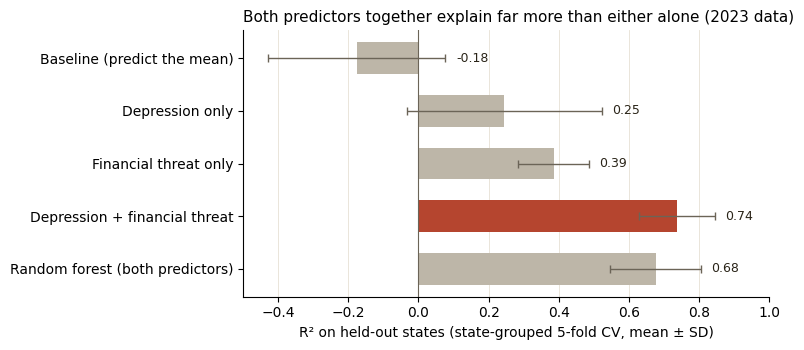

In [7]:
r = results_23["R2 state-grouped"].iloc[::-1]
err = results_23["R2 state-grouped std"].iloc[::-1]
colors = ["#b5452f" if m == "Depression + financial threat" else "#bdb6a8" for m in r.index]

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(r.index, r.values, xerr=err.values, color=colors, height=0.6,
        error_kw={"ecolor": "#6b6457", "elinewidth": 1, "capsize": 3})
for y, (v, e) in enumerate(zip(r.values, err.values)):
    ax.text(max(v + e, 0) + 0.03, y, f"{v:.2f}", va="center", fontsize=9, color="#2a2418")
ax.axvline(0, color="#6b6457", linewidth=0.8)
ax.set_xlim(-0.5, 1)
ax.set_xlabel("R² on held-out states (state-grouped 5-fold CV, mean ± SD)")
ax.set_title("Both predictors together explain far more than either alone (2023 data)", loc="left", fontsize=11)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.grid(axis="x", color="#e6e0d4", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 4. Effect sizes with honest uncertainty

Standardized coefficients (z-scored variables) let the two predictors be compared directly. Standard errors are **clustered by state**, because counties in the same state are not independent observations.

In [8]:
def standardized_fit(d):
    z = d[model_cols].apply(lambda c: (c - c.mean()) / c.std())
    fit = smf.ols("distress ~ depression + financial_threat", data=z).fit(
        cov_type="cluster", cov_kwds={"groups": pd.factorize(d["stateabbr"])[0]})
    t = fit.summary2().tables[1].loc[["depression", "financial_threat"], ["Coef.", "Std.Err.", "[0.025", "0.975]", "P>|z|"]]
    return t

effects = pd.concat({
    "2023 crude": standardized_fit(d23),
    "2023 age-adjusted": standardized_fit(a23),
    "2022 crude": standardized_fit(d22),
})
effects.round(3)

Coef.  Std.Err.  [0.025  0.975]  P>|z|
2023 crude        depression        0.587     0.047   0.495   0.679    0.0
                  financial_threat  0.639     0.047   0.547   0.732    0.0
2023 age-adjusted depression        0.640     0.051   0.541   0.739    0.0
                  financial_threat  0.611     0.048   0.517   0.705    0.0
2022 crude        depression        0.607     0.055   0.499   0.715    0.0
                  financial_threat  0.568     0.038   0.493   0.643    0.0

In [9]:
# Raw coefficients (percentage points of distress per point of predictor), next to the state-level model in Health.ipynb
raw_coefs = {"State model (Health.ipynb, n=52)": {"intercept": 6.163, "depression": 0.313, "financial_threat": 0.277}}
for label, d in [("County 2023 crude", d23), ("County 2023 age-adjusted", a23), ("County 2022 crude", d22)]:
    m = LinearRegression().fit(d[["depression", "financial_threat"]], d["distress"])
    raw_coefs[f"{label} (n={len(d):,})"] = {"intercept": m.intercept_, "depression": m.coef_[0], "financial_threat": m.coef_[1]}
pd.DataFrame(raw_coefs).T.round(3)

,intercept,depression,financial_threat
"State model (Health.ipynb, n=52)",6.163,0.313,0.277
"County 2023 crude (n=2,299)",5.271,0.364,0.276
"County 2023 age-adjusted (n=2,299)",5.887,0.381,0.256
"County 2022 crude (n=2,417)",4.623,0.396,0.274


## 5. Crude vs age-adjusted prevalence

Counties differ a lot in age structure. If the relationship were driven by age (older or younger counties having both more depression and more distress), it would weaken after age adjustment.

In [10]:
results_a23 = compare_models(a23)
pd.DataFrame({
    "crude R2 (state-grouped)": results_23["R2 state-grouped"],
    "age-adjusted R2 (state-grouped)": results_a23["R2 state-grouped"],
    "crude RMSE": results_23["RMSE state-grouped"],
    "age-adjusted RMSE": results_a23["RMSE state-grouped"],
}).round(3)

,crude R2 (state-grouped),age-adjusted R2 (state-grouped),crude RMSE,age-adjusted RMSE
model,,,,
Baseline (predict the mean),-0.176,-0.107,2.009,2.017
Depression only,0.245,0.335,1.579,1.539
Financial threat only,0.386,0.351,1.457,1.548
Depression + financial threat,0.737,0.754,0.900,0.902
Random forest (both predictors),0.677,0.693,1.005,1.025


## 6. Out-of-time test: train on 2022, predict 2023

The model is fit only on 2022 data and then predicts 2023 distress. Some 2023 states had no financial data in 2022, so for those counties this is both a new year **and** a new state.

In [11]:
features = ["depression", "financial_threat"]
temporal = LinearRegression().fit(d22[features], d22["distress"])
test = d23.copy()
test["predicted"] = temporal.predict(test[features])
test["state in 2022 training"] = test["stateabbr"].isin(d22["stateabbr"])

def score(g):
    return pd.Series({
        "counties": len(g),
        "states": g["stateabbr"].nunique(),
        "R2": r2_score(g["distress"], g["predicted"]),
        "RMSE": mean_squared_error(g["distress"], g["predicted"]) ** 0.5,
        "mean error (pred - actual)": (g["predicted"] - g["distress"]).mean(),
    })

print("2022 model:", f"distress = {temporal.intercept_:.3f} + {temporal.coef_[0]:.3f}·depression + {temporal.coef_[1]:.3f}·financial_threat")
print("New 2023 states:", ", ".join(sorted(set(d23["stateabbr"]) - set(d22["stateabbr"]))))
pd.DataFrame({
    "all 2023 counties": score(test),
    "states seen in 2022": score(test[test["state in 2022 training"]]),
    "states NOT seen in 2022": score(test[~test["state in 2022 training"]]),
}).T.round(3)

2022 model: distress = 4.623 + 0.396·depression + 0.274·financial_threat
New 2023 states: AR, HI, IL, LA, ND, NY, VA


,counties,states,R2,RMSE,mean error (pred - actual)
all 2023 counties,2299.0,40.0,0.806,0.873,0.065
states seen in 2022,1805.0,33.0,0.776,0.905,0.077
states NOT seen in 2022,494.0,7.0,0.885,0.745,0.022


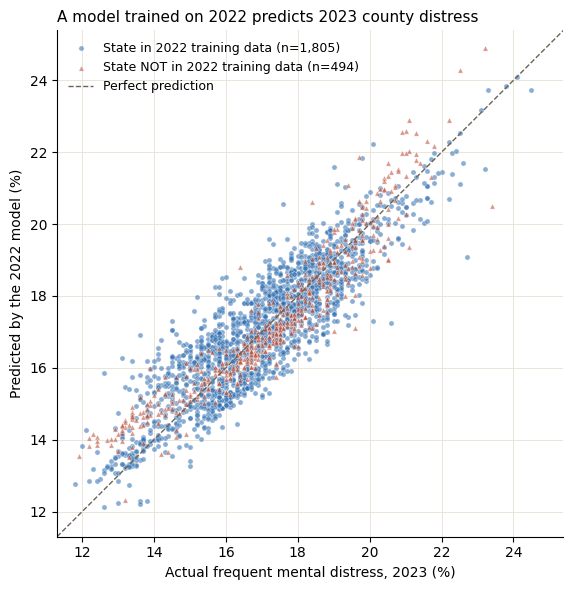

In [12]:
fig, ax = plt.subplots(figsize=(6.4, 6))
groups = [(True, "#2b6cb0", "o", "State in 2022 training data"),
          (False, "#b5452f", "^", "State NOT in 2022 training data")]
for seen, color, marker, label in groups:
    g = test[test["state in 2022 training"] == seen]
    ax.scatter(g["distress"], g["predicted"], s=14, marker=marker, color=color, alpha=0.55,
               edgecolors="white", linewidths=0.4, label=f"{label} (n={len(g):,})")
lo, hi = test[["distress", "predicted"]].min().min() - 0.5, test[["distress", "predicted"]].max().max() + 0.5
ax.plot([lo, hi], [lo, hi], color="#6b6457", linewidth=1, linestyle="--", label="Perfect prediction")
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
ax.set_xlabel("Actual frequent mental distress, 2023 (%)")
ax.set_ylabel("Predicted by the 2022 model (%)")
ax.set_title("A model trained on 2022 predicts 2023 county distress", loc="left", fontsize=11)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.grid(color="#e6e0d4", linewidth=0.6); ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

## 7. Is the poster formula accurate for individual counties?

The formula on the poster was fit on 52 state averages:

`distress = 6.163 + 0.313 · depression + 0.277 · financial_threat`

Here it is applied, unchanged, to every 2023 county. That's a strict test, because the formula never saw county data. For comparison, the county model is scored **out-of-state**: each county is predicted by a model fitted with its whole state held out.

In [13]:
POSTER = {"intercept": 6.162857696868079, "depression": 0.31342386, "financial_threat": 0.27670656}

spot = d23[["locationid", "stateabbr", "locationname", "depression", "financial_threat", "distress"]].copy()
spot["poster formula"] = POSTER["intercept"] + POSTER["depression"] * spot["depression"] + POSTER["financial_threat"] * spot["financial_threat"]
spot["county model (out-of-state)"] = cross_val_predict(LinearRegression(), d23[features], d23["distress"],
                                                        cv=GroupKFold(n_splits=5), groups=d23["stateabbr"])
# Baltimore city and Baltimore County share the name "Baltimore"
spot["county"] = spot["locationname"] + np.where(spot["locationid"] == "24510", " (city)", "") + ", " + spot["stateabbr"]

def accuracy(pred):
    err = pred - spot["distress"]
    return pd.Series({
        "R2": r2_score(spot["distress"], pred),
        "RMSE (pp)": mean_squared_error(spot["distress"], pred) ** 0.5,
        "mean error (pred - actual)": err.mean(),
        "% within ±1 pp": (err.abs() <= 1).mean() * 100,
        "% within ±2 pp": (err.abs() <= 2).mean() * 100,
        "worst miss (pp)": err.abs().max(),
    })

pd.DataFrame({m: accuracy(spot[m]) for m in ["poster formula", "county model (out-of-state)"]}).T.round(2)

,R2,RMSE (pp),mean error (pred - actual),% within ±1 pp,% within ±2 pp,worst miss (pp)
poster formula,0.79,0.91,-0.25,71.99,97.52,4.34
county model (out-of-state),0.79,0.91,-0.01,72.94,97.61,3.89


### Maryland, county by county

In [14]:
md_counties = spot[spot["stateabbr"] == "MD"].copy()
md_counties["error"] = md_counties["poster formula"] - md_counties["distress"]
(md_counties.sort_values("distress", ascending=False)
 [["county", "depression", "financial_threat", "distress", "poster formula", "error"]]
 .rename(columns={"distress": "actual distress"})
 .round(2).reset_index(drop=True))

measure,county,depression,financial_threat,actual distress,poster formula,error
0,"Allegany, MD",25.7,14.15,18.9,18.13,-0.77
1,"Somerset, MD",20.9,19.08,18.5,17.99,-0.51
2,"Baltimore (city), MD",23.5,21.28,18.4,19.42,1.02
3,"Caroline, MD",24.2,15.40,18.1,18.01,-0.09
4,"Wicomico, MD",21.7,13.45,17.6,16.69,-0.91
5,"Cecil, MD",23.2,10.78,17.4,16.42,-0.98
6,"Dorchester, MD",20.2,15.90,17.0,16.89,-0.11
7,"Washington, MD",22.9,12.98,16.9,16.93,0.03
8,"Garrett, MD",21.0,9.88,16.4,15.48,-0.92
9,"St. Mary's, MD",21.2,10.05,16.4,15.59,-0.81


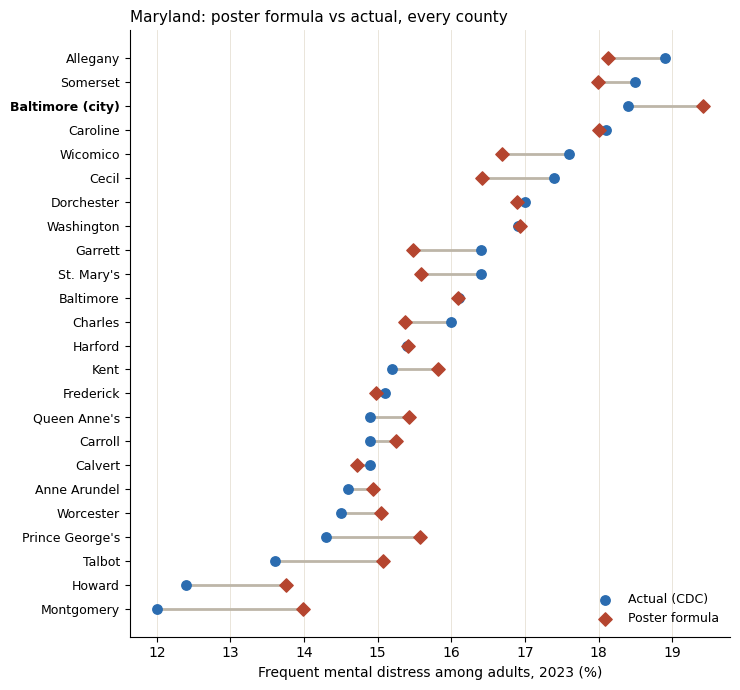

In [15]:
m = md_counties.sort_values("distress")
fig, ax = plt.subplots(figsize=(7.5, 7))
y = np.arange(len(m))
ax.hlines(y, m["distress"], m["poster formula"], color="#bdb6a8", linewidth=2)
ax.scatter(m["distress"], y, s=46, color="#2b6cb0", marker="o", zorder=3, label="Actual (CDC)")
ax.scatter(m["poster formula"], y, s=46, color="#b5452f", marker="D", zorder=3, label="Poster formula")
ax.set_yticks(y)
ax.set_yticklabels([c.replace(", MD", "") for c in m["county"]], fontsize=9)
for tick in ax.get_yticklabels():
    if tick.get_text() == "Baltimore (city)":
        tick.set_fontweight("bold")
ax.set_xlabel("Frequent mental distress among adults, 2023 (%)")
ax.set_title("Maryland: poster formula vs actual, every county", loc="left", fontsize=11)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.grid(axis="x", color="#e6e0d4", linewidth=0.6); ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

### Where does the formula miss most?

The ten counties with the largest misses (out-of-state county model), and the states where predictions are biased in one direction. A systematic state-level bias points to something the two predictors don't capture.

In [16]:
spot["error"] = spot["county model (out-of-state)"] - spot["distress"]
worst = spot.reindex(spot["error"].abs().sort_values(ascending=False).index).head(10)
worst[["county", "locationid", "depression", "financial_threat", "distress", "county model (out-of-state)", "error"]].round(2).reset_index(drop=True)

measure,county,locationid,depression,financial_threat,distress,county model (out-of-state),error
0,"Madison, ID",16065,27.9,12.48,22.7,18.81,-3.89
1,"Chattahoochee, GA",13053,21.0,15.73,20.6,17.05,-3.55
2,"Mora, NM",35033,17.7,15.42,12.6,16.13,3.53
3,"Harding, NM",35021,20.4,15.40,13.6,17.06,3.46
4,"Radford, VA",51750,30.0,14.52,23.4,20.15,-3.25
5,"Santa Fe, NM",35049,21.9,10.90,13.1,16.28,3.18
6,"Luna, NM",35029,22.6,25.45,17.6,20.73,3.13
7,"Guadalupe, NM",35019,19.2,20.90,15.2,18.23,3.03
8,"San Miguel, NM",35047,19.5,18.10,14.5,17.53,3.03
9,"Bulloch, GA",13031,21.4,15.32,20.1,17.10,-3.00


In [17]:
state_bias = spot.groupby("stateabbr")["error"].agg(["mean", "count"]).rename(columns={"mean": "mean error (pp)", "count": "counties"})
state_bias = state_bias.sort_values("mean error (pp)")
print("Most UNDER-predicted states (formula too low):")
print(state_bias.head(5).round(2).to_string())
print("\nMost OVER-predicted states (formula too high):")
print(state_bias.tail(5).round(2).to_string())

Most UNDER-predicted states (formula too low):
           mean error (pp)  counties
stateabbr                           
NJ                   -1.23        21
NV                   -1.17        17
GA                   -1.16       159
IA                   -0.91        99
KS                   -0.66       105

Most OVER-predicted states (formula too high):
           mean error (pp)  counties
stateabbr                           
NC                    1.00       100
RI                    1.02         5
MN                    1.15        87
NM                    2.20        33
DC                    2.31         1


## 8. Findings

1. **The relationship holds at county level, with 44× more data.** 2,299 counties in 40 states, compared with 52 state rows. The raw coefficients are close to the state model (depression 0.36 vs 0.31, financial threat 0.28 vs 0.28).
2. **The model generalizes to states it has never seen.** State-grouped 5-fold CV gives R² = 0.74 ± 0.11 (RMSE 0.90 percentage points). Random-split CV (0.81) is optimistic because neighbouring counties leak between train and test.
3. **Depression and financial threat explain different parts of distress.** The two are almost uncorrelated across counties (r = 0.08). Each alone gives R² ≈ 0.25–0.39 on held-out states, and together they give 0.74. Standardized effects are about equal (≈ 0.6 SD each, 95% CIs well away from zero with state-clustered SEs). So financial threat is not a stand-in for depression; it adds its own signal.
4. **Linear regression beats random forest** on the same data (0.74 vs 0.68 on held-out states). The relationship is close to linear, and the simpler model is more accurate as well as easier to interpret.
5. **Not explained by age structure.** With age-adjusted prevalence, R² is 0.75 and the effects are essentially unchanged.
6. **Stable over time.** A model fit only on 2022 data predicts 2023 county distress with R² = 0.81 (RMSE 0.87). That includes R² = 0.89 in 7 states that had no 2022 data at all.
7. **The poster formula works on individual counties.** Applied unchanged to 2,299 counties, the state-fit formula gets R² = 0.79 (RMSE 0.91 pp). **72% of counties are within ±1 percentage point and 97.5% within ±2.** It runs about 0.25 pp low on average. In Maryland, Baltimore city is predicted at 19.4% vs 18.4% actual. The largest Maryland misses are the wealthiest suburbs (Montgomery +2.0, Talbot +1.5, Howard +1.4 pp over-predicted).
8. **The misses point to what's missing.** Several of the largest under-predictions are college or military-base counties: Madison ID (BYU–Idaho), Radford VA (Radford University), Bulloch GA (Georgia Southern), Chattahoochee GA (Fort Benning). These counties have young adult populations, which suggests age composition as a next predictor; that's a hypothesis, not tested here. New Mexico is over-predicted by 2.2 pp on average across 33 counties, a regional pattern the two predictors don't capture.

## Limitations

- **Ecological data.** These are county prevalences, not individuals. The results say counties with more financial hardship have more distress, not that any given person's hardship causes their distress.
- **PLACES values are model-based estimates.** CDC produces county numbers by combining BRFSS survey responses with county demographics (multilevel regression and post-stratification). Part of the county-to-county correlation may come from that shared estimation model, so R² here is likely an upper bound.
- **40 of 51 states.** States that did not field the social-needs module in a given year (2023: CO, FL, OR, SD, TN, TX, VT, WA, WY; KY and PA have no 2023 PLACES data at all) are excluded rather than imputed. Results may not transfer to them.
- **No other controls yet.** Income, poverty, unemployment and rurality (Census ACS, USDA codes) are the natural next confounders to add.
- **Unweighted.** Each county counts equally regardless of population.